# Tiempo de ejecución

In [6]:
import os
import re

directory = os.fsencode("../logs")

dict_cpu = dict()
dict_gpu = dict()
dict_mgpu = dict()

time_pattern = re.compile(r"^real\t(\d+)m([\d.]+)s$")

filename_patterns = ["grad_acc", "ipex", "batch16", "batch32", "fp16", "fp32"]

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.endswith(".err"):
        for line in open(os.path.join(os.fsdecode(directory),filename)):
            matches = re.findall(time_pattern, line)

            if len(matches) != 1:
                continue
            
            match = matches[0]

            seconds = float(match[0])*60+float(match[1])

            print(f"{filename}: {seconds} seconds.")

            string_list = []

            for pattern in filename_patterns:
                if filename.find("_"+pattern+"_") != -1:
                    string_list.append(pattern)
            
            if filename.find("_cpu_") != -1:
                dict_cpu[" ".join(string_list)] = seconds
            elif filename.find("_gpu_") != -1:
                dict_gpu[" ".join(string_list)] = seconds
            elif filename.find("_mgpu_") != -1:
                dict_mgpu[" ".join(string_list)] = seconds
            else:
                print(f"ERROR: no se encontraron las subcadenas _cpu_, _gpu_ o _mgpu_ en el nombre del fichero {filename}")
                exit()

distilbert_job_train_cpu_batch16_2904.err: 143.126 seconds.
distilbert_job_train_cpu_batch16_grad_acc_2903.err: 124.216 seconds.
distilbert_job_train_cpu_batch16_grad_acc_ipex_2992.err: 110.09700000000001 seconds.
distilbert_job_train_cpu_batch16_ipex_2997.err: 122.983 seconds.
distilbert_job_train_cpu_batch32_2905.err: 141.743 seconds.
distilbert_job_train_cpu_batch32_grad_acc_2906.err: 141.999 seconds.
distilbert_job_train_cpu_batch32_grad_acc_ipex_2999.err: 119.444 seconds.
distilbert_job_train_cpu_batch32_ipex_4502.err: 114.74199999999999 seconds.
distilbert_job_train_gpu_batch16_fp16_2908.err: 28.783 seconds.
distilbert_job_train_gpu_batch16_fp16_grad_acc_2907.err: 37.91 seconds.
distilbert_job_train_gpu_batch16_fp32_2910.err: 46.25 seconds.
distilbert_job_train_gpu_batch16_fp32_grad_acc_2909.err: 45.443 seconds.
distilbert_job_train_gpu_batch32_fp16_2912.err: 28.318 seconds.
distilbert_job_train_gpu_batch32_fp16_grad_acc_2911.err: 27.863 seconds.
distilbert_job_train_gpu_batch32_

{'batch16': 143.126, 'grad_acc batch16': 124.216, 'grad_acc ipex batch16': 110.09700000000001, 'ipex batch16': 122.983, 'batch32': 141.743, 'grad_acc batch32': 141.999, 'grad_acc ipex batch32': 119.444, 'ipex batch32': 114.74199999999999}


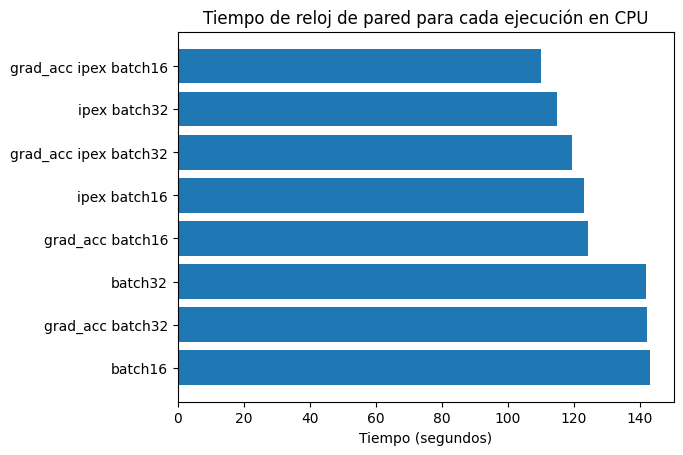

{'batch16 fp16': 28.783, 'grad_acc batch16 fp16': 37.91, 'batch16 fp32': 46.25, 'grad_acc batch16 fp32': 45.443, 'batch32 fp16': 28.318, 'grad_acc batch32 fp16': 27.863, 'batch32 fp32': 37.037, 'grad_acc batch32 fp32': 38.405}


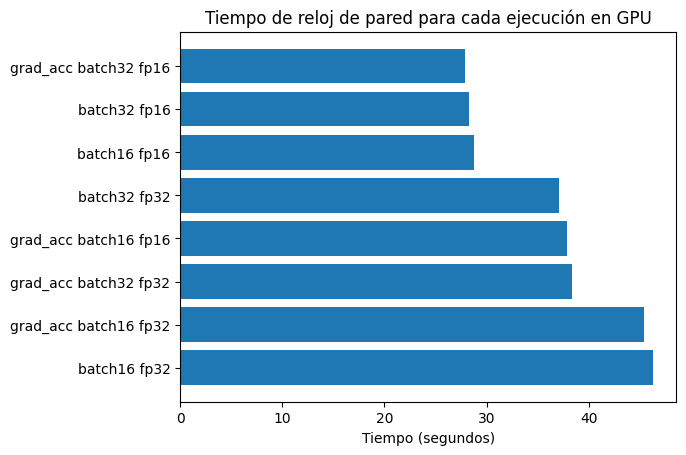

{'batch16 fp16': 45.896, 'grad_acc batch16 fp16': 43.932, 'batch16 fp32': 33.708, 'grad_acc batch16 fp32': 40.633, 'batch32 fp16': 37.699, 'grad_acc batch32 fp16': 45.641, 'batch32 fp32': 40.728, 'grad_acc batch32 fp32': 41.182}


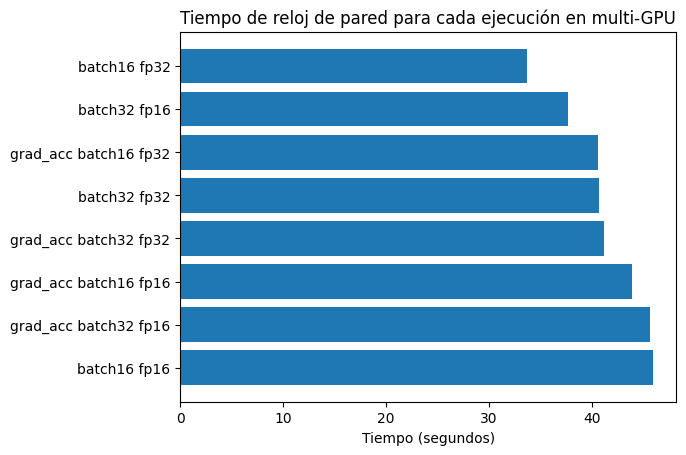

In [20]:
import matplotlib.pyplot as plt
import numpy as np

for iter_tuple in [("CPU",dict_cpu), ("GPU",dict_gpu), ("multi-GPU",dict_mgpu)]:

    my_name = iter_tuple[0]
    my_dict = iter_tuple[1]

    fig, ax = plt.subplots()

    y_pos = np.arange(len(my_dict))

    print(my_dict)

    ordered_names = list(my_dict.keys())
    ordered_values  =list(my_dict.values())

    ordered_names = sorted(ordered_names,key=my_dict.get)
    ordered_values = sorted(ordered_values)

    ax.barh(y_pos, ordered_values, align="center")
    ax.set_yticks(y_pos, labels=ordered_names)
    ax.invert_yaxis()
    ax.set_xlabel("Tiempo (segundos)")
    ax.set_title(f"Tiempo de reloj de pared para cada ejecución en {my_name}")

    plt.show()

# Uso de memoria

In [11]:
import os

directory = os.fsencode("../results")

dict_cpu_ram = dict()
dict_gpu_ram = dict()
dict_mgpu_ram = dict()

filename_patterns = ["gradacc", "ipex", "batch16", "batch32", "fp16", "fp32"]

for file in os.listdir(directory):
    filename = os.fsdecode(file)
    if filename.startswith("memory"):
        max_ram_usage = 0
        max_vram_usage = 0
        for line in open(os.path.join(os.fsdecode(directory),filename)):
            data = line.split(",")

            if data[0] != "0":
                continue
                
            if float(data[2]) > max_ram_usage:
                max_ram_usage = float(data[2])
            if filename.find("_cpu_") == -1 and float(data[3]) > max_vram_usage:
                max_vram_usage = float(data[3])

        string_list = []

        for pattern in filename_patterns:
            if filename.find(pattern) != -1:
                string_list.append(pattern)
        
        if filename.find("_cpu_") != -1:
            dict_cpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        elif filename.find("_gpu_") != -1:
            dict_gpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        elif filename.find("_mgpu_") != -1:
            dict_mgpu_ram[" ".join(string_list)] = (max_ram_usage,max_vram_usage)
        else:
            print(f"ERROR: no se encontraron las subcadenas _cpu_, _gpu_ o _mgpu_ en el nombre del fichero {filename}")
            exit()

{'batch16': (2667.67578125, 0), 'gradacc batch16': (2519.35546875, 0), 'gradacc ipex batch16': (2863.49609375, 0), 'ipex batch16': (2908.015625, 0), 'batch32': (3788.5390625, 0), 'gradacc batch32': (3716.984375, 0), 'gradacc ipex batch32': (3948.80859375, 0), 'ipex batch32': (4049.28125, 0)}


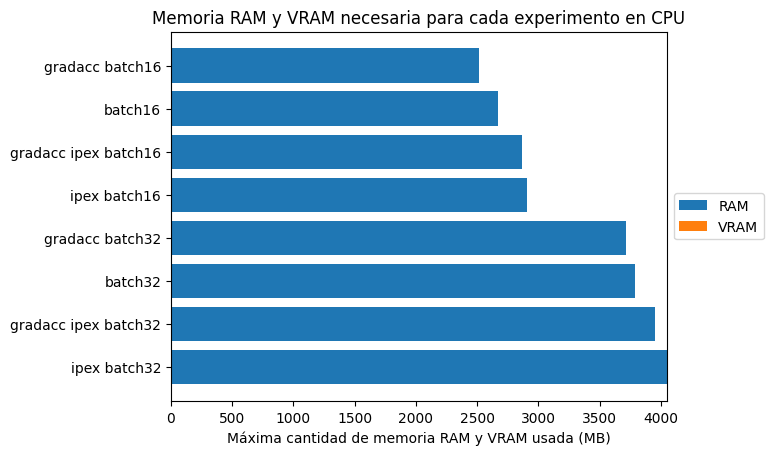

{'batch16 fp16': (1210.10546875, 1056.24658203125), 'gradacc batch16 fp16': (1206.71484375, 787.1279296875), 'batch16 fp32': (1103.98046875, 1058.24560546875), 'gradacc batch16 fp32': (1105.2890625, 788.751953125), 'batch32 fp16': (1215.04296875, 1063.51220703125), 'gradacc batch32 fp16': (1216.26953125, 791.7685546875), 'batch32 fp32': (1090.23828125, 1046.76123046875), 'gradacc batch32 fp32': (1091.54296875, 786.017578125)}


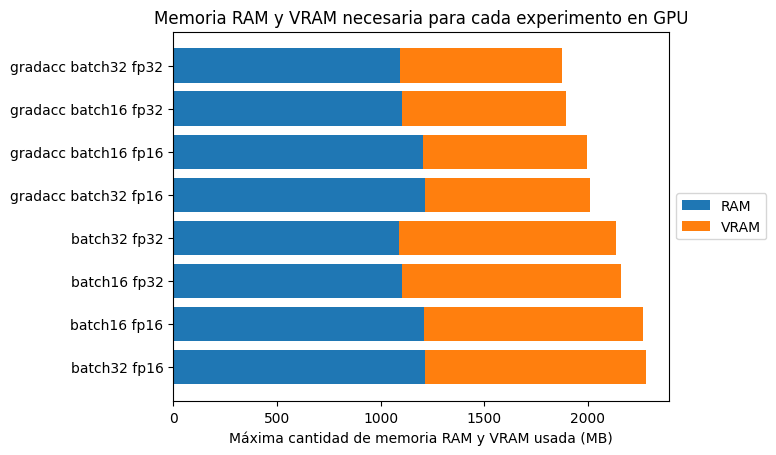

{'batch16 fp16': (1570.78125, 1045.03564453125), 'gradacc batch16 fp16': (1569.24609375, 1045.03564453125), 'batch16 fp32': (1377.58984375, 1045.75244140625), 'gradacc batch16 fp32': (1375.8203125, 1045.75244140625), 'batch32 fp16': (1568.30859375, 1044.63134765625), 'gradacc batch32 fp16': (1538.0703125, 1044.63134765625), 'batch32 fp32': (1351.01171875, 1300.61669921875), 'gradacc batch32 fp32': (1347.57421875, 1042.76806640625)}


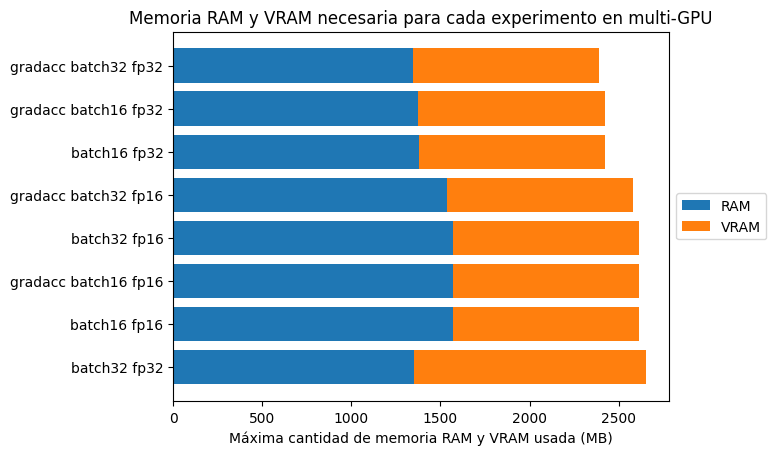

In [19]:
import matplotlib.pyplot as plt
import numpy as np

for iter_tuple in [("CPU",dict_cpu_ram), ("GPU",dict_gpu_ram), ("multi-GPU",dict_mgpu_ram)]:

    my_name = iter_tuple[0]
    my_dict = iter_tuple[1]

    fig, ax = plt.subplots()

    y_pos = np.arange(len(my_dict))

    print(my_dict)

    ordered_names = list(my_dict.keys())
    ordered_values  =list(my_dict.values())

    ordered_names = sorted(ordered_names,key=lambda key:my_dict[key][0]+my_dict[key][1])
    ordered_values = sorted(ordered_values,key=lambda value:value[0]+value[1])

    ax.barh(y_pos, [ram for (ram,vram) in ordered_values], align="center", label="RAM")
    ax.barh(y_pos, [vram for (ram,vram) in ordered_values], align="center", label="VRAM", left = [ram for (ram,vram) in ordered_values])
    ax.set_yticks(y_pos, labels=ordered_names)
    ax.invert_yaxis()
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.set_xlabel("Máxima cantidad de memoria RAM y VRAM usada (MB)")
    ax.set_title(f"Memoria RAM y VRAM necesaria para cada experimento en {my_name}")

    plt.show()